# Machine Learning Classification Project

# Breast Cancer Wisconsin Dataset

# Objective
To build and compare two machine learning classification algorithms, Logistic Regression and Random Forest, and evaluate their performance using Accuracy, Precision, Recall, F1-Score, and ROC-AUC.

# 1) Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer

print("Libraries imported successfully!")

Libraries imported successfully!


# 2) Load Dataset

In [2]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

print("Dataset loaded successfully!")
print("Features:", X.shape)
print("Target:", y.shape)

Dataset loaded successfully!
Features: (569, 30)
Target: (569,)


# 3) Exploratory Data Analysis

In [3]:
print("First 5 rows:")
display(X.head())

print("\nDataset information:")
X.info()

print("\nTarget classes:")
print(y.value_counts())

First 5 rows:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness erro

# 4) Missing-value check

In [4]:
print("Missing values in each column:")
print(X.isnull().sum().sum())

Missing values in each column:
0


# 5) Data Preprocessing

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 455
Testing samples: 114


# 6) Feature Scaling

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed!")
print("Training data shape:", X_train_scaled.shape)
print("Testing data shape:", X_test_scaled.shape)

Feature scaling completed!
Training data shape: (455, 30)
Testing data shape: (114, 30)


# 7) Logistics Regression

In [7]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(max_iter=1000, random_state=42)

logistic_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


# 8) Logistic Regression Prediction

In [8]:
y_pred_logistic = logistic_model.predict(X_test_scaled)

print("Predictions generated!")
print("First 10 predictions:", y_pred_logistic[:10])

Predictions generated!
First 10 predictions: [0 1 0 1 0 1 1 0 0 0]


# 9) Logistic Regression Evaluation

In [9]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy = accuracy_score(y_test, y_pred_logistic)
precision = precision_score(y_test, y_pred_logistic)
recall = recall_score(y_test, y_pred_logistic)
f1 = f1_score(y_test, y_pred_logistic)

y_prob_logistic = logistic_model.predict_proba(X_test_scaled)[:, 1]
roc_auc = roc_auc_score(y_test, y_prob_logistic)

print("Logistic Regression Results")
print("---------------------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

Logistic Regression Results
---------------------------
Accuracy : 0.9825
Precision: 0.9861
Recall   : 0.9861
F1-Score : 0.9861
ROC-AUC  : 0.9954


# 10) Cross-Validation

In [10]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    logistic_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("5-Fold Cross-Validation Scores:")
print(cv_scores)

print("\nMean CV Accuracy:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())

5-Fold Cross-Validation Scores:
[0.96703297 0.97802198 0.96703297 1.         0.98901099]

Mean CV Accuracy: 0.9802197802197803
Standard Deviation: 0.012815278889769896


## 11) Random Forest

In [11]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


# 12) Random Forest Prediction

In [12]:
y_pred_rf = random_forest.predict(X_test)

print("Random Forest predictions generated!")
print("First 10 predictions:", y_pred_rf[:10])

Random Forest predictions generated!
First 10 predictions: [0 1 0 0 0 1 1 0 0 0]


# 13) Random Forest Evaluation

In [13]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

y_prob_rf = random_forest.predict_proba(X_test)[:, 1]
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest Results")
print("---------------------")
print(f"Accuracy : {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall   : {recall_rf:.4f}")
print(f"F1-Score : {f1_rf:.4f}")
print(f"ROC-AUC  : {roc_auc_rf:.4f}")

Random Forest Results
---------------------
Accuracy : 0.9561
Precision: 0.9589
Recall   : 0.9722
F1-Score : 0.9655
ROC-AUC  : 0.9937


# 14) Random Forest Cross-Validation

In [14]:
rf_cv_scores = cross_val_score(
    random_forest,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("Random Forest 5-Fold Cross-Validation Scores:")
print(rf_cv_scores)

print("\nMean CV Accuracy:", rf_cv_scores.mean())
print("Standard Deviation:", rf_cv_scores.std())

Random Forest 5-Fold Cross-Validation Scores:
[0.96703297 0.98901099 0.92307692 0.93406593 0.95604396]

Mean CV Accuracy: 0.953846153846154
Standard Deviation: 0.023466106048420463


# 15) Model Comparison Table

In [15]:
results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"],
    "Logistic Regression": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ],
    "Random Forest": [
        accuracy_rf,
        precision_rf,
        recall_rf,
        f1_rf,
        roc_auc_rf
    ]
})

display(results)

,Metric,Logistic Regression,Random Forest
0,Accuracy,0.982456,0.956140
1,Precision,0.986111,0.958904
2,Recall,0.986111,0.972222
3,F1-Score,0.986111,0.965517
4,ROC-AUC,0.995370,0.993717


# 16) Confusion Matrices

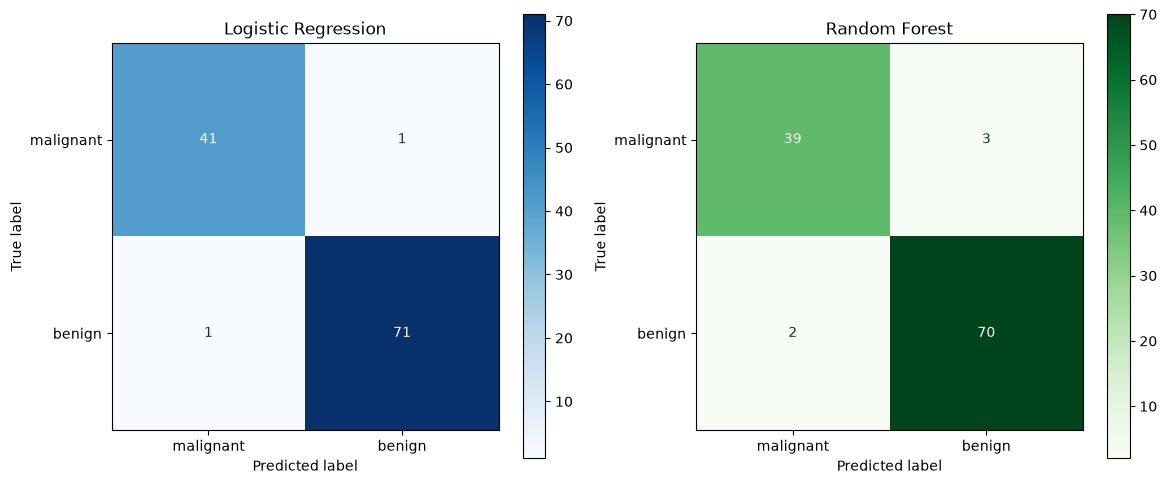

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_logistic = confusion_matrix(y_test, y_pred_logistic)
cm_rf = confusion_matrix(y_test, y_pred_rf)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(
    confusion_matrix=cm_logistic,
    display_labels=data.target_names
).plot(ax=axes[0], cmap="Blues")

axes[0].set_title("Logistic Regression")

ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=data.target_names
).plot(ax=axes[1], cmap="Greens")

axes[1].set_title("Random Forest")

plt.tight_layout()
plt.show()

# 17) ROC Curve

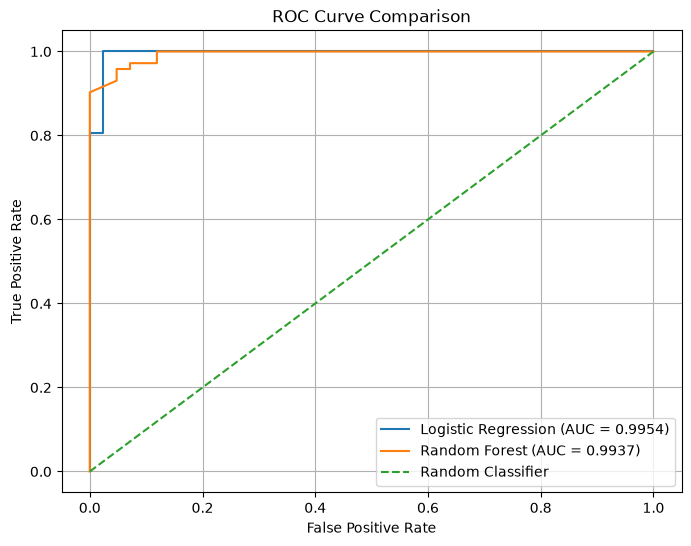

In [17]:
from sklearn.metrics import roc_curve

fpr_logistic, tpr_logistic, _ = roc_curve(y_test, y_prob_logistic)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_logistic,
    tpr_logistic,
    label=f"Logistic Regression (AUC = {roc_auc:.4f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {roc_auc_rf:.4f})"
)

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid()
plt.show()

In [18]:
print("Random Forest CV Scores:")
print(rf_cv_scores)

print("\nMean CV Accuracy:", rf_cv_scores.mean())
print("Standard Deviation:", rf_cv_scores.std())

Random Forest CV Scores:
[0.96703297 0.98901099 0.92307692 0.93406593 0.95604396]

Mean CV Accuracy: 0.953846153846154
Standard Deviation: 0.023466106048420463


## Conclusion

Two classification algorithms, Logistic Regression and Random Forest, were trained and evaluated on the Breast Cancer Wisconsin dataset.

Logistic Regression achieved an accuracy of 98.25%, precision of 98.61%, recall of 98.61%, F1-score of 98.61%, and ROC-AUC of 99.54% on the test set. Its mean 5-fold cross-validation accuracy was 98.02% with a standard deviation of 1.34%.

Random Forest achieved an accuracy of 95.61%, precision of 95.89%, recall of 97.22%, F1-score of 96.55%, and ROC-AUC of 99.37%. Its mean 5-fold cross-validation accuracy was 95.38% with a standard deviation of 2.35%.

Based on the evaluation results, Logistic Regression performed better than Random Forest on this dataset. It achieved higher test-set performance across all five metrics and also demonstrated higher and more consistent cross-validation accuracy.

Therefore, Logistic Regression was selected as the preferred model for this classification task.